---
## 1️⃣ Import Libraries

We import all required libraries upfront for clarity:
- **`pandas` / `numpy`** — data manipulation and numerical operations
- **`matplotlib` / `seaborn`** — data visualization
- **`sklearn`** — preprocessing, splitting, and machine learning models


In [1]:
# --- Core Data Manipulation ---
import pandas as pd
import numpy as np
import math

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing & Splitting ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Machine Learning Models ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
# If you have xgboost installed, it's highly recommended
# from xgboost import XGBClassifier

print('All libraries imported successfully ✅')


All libraries imported successfully ✅


---
## 2️⃣ Load Data

We load two CSV files:
- **`train_data.csv`** — labeled data used to train and evaluate the model (contains `Is high risk` target column)
- **`test_data.csv`** — unlabeled data for final predictions


In [2]:
train_data = pd.read_csv('train_data.csv')
test_data  = pd.read_csv('test_data.csv')

print(f'Train shape: {train_data.shape}')
print(f'Test  shape: {test_data.shape}')


Train shape: (29165, 20)
Test  shape: (7292, 20)


---
## 3️⃣ Exploratory Data Analysis (EDA)

Before any modelling we need to understand:
- What the data looks like (`head`)
- Column types, non-null counts, and memory usage (`info`)
- Which columns have missing values (`isnull().sum()`)


In [3]:
train_data.head()


,ID,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Employment length,Has a mobile phone,Has a work phone,Has a phone,Has an email,Job title,Family member count,Account age,Is high risk
0,5037048,M,Y,Y,0,135000.0,Working,Secondary / secondary special,Married,With parents,-16271,-3111,1,0,0,0,Core staff,2.0,-17.0,0
1,5044630,F,Y,N,1,135000.0,Commercial associate,Higher education,Single / not married,House / apartment,-10130,-1651,1,0,0,0,Accountants,2.0,-1.0,0
2,5079079,F,N,Y,2,180000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-12821,-5657,1,0,0,0,Laborers,4.0,-38.0,0
3,5112872,F,Y,Y,0,360000.0,Commercial associate,Higher education,Single / not married,House / apartment,-20929,-2046,1,0,0,1,Managers,1.0,-11.0,0
4,5105858,F,N,N,0,270000.0,Working,Secondary / secondary special,Separated,House / apartment,-16207,-515,1,0,1,0,NaN,1.0,-41.0,0


In [4]:
train_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29165 entries, 0 to 29164
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   29165 non-null  int64  
 1   Gender               29165 non-null  object 
 2   Has a car            29165 non-null  object 
 3   Has a property       29165 non-null  object 
 4   Children count       29165 non-null  int64  
 5   Income               29165 non-null  float64
 6   Employment status    29165 non-null  object 
 7   Education level      29165 non-null  object 
 8   Marital status       29165 non-null  object 
 9   Dwelling             29165 non-null  object 
 10  Age                  29165 non-null  int64  
 11  Employment length    29165 non-null  int64  
 12  Has a mobile phone   29165 non-null  int64  
 13  Has a work phone     29165 non-null  int64  
 14  Has a phone          29165 non-null  int64  
 15  Has an email         29165 non-null 

In [5]:
# Count missing values per column
missing = train_data.isnull().sum()
print(missing[missing > 0])


Job title    9027
dtype: int64


---
## 4️⃣ Handling Missing Values

The only column with significant missing values is **`Job title`**.

### Strategy — Group-Based Mode Imputation
Instead of filling with a global mode (which ignores context), we use a **3-level imputation hierarchy**:

1. **Primary:** Fill based on the most common job title within the same `Education level` + `Gender` + income quantile group.
2. **Fallback:** If a group has no known job title, fill using `Education level` alone.
3. **Last resort:** Assign `'unemployed'` to any remaining nulls.

> 💡 This preserves realistic relationships — e.g., a high-income, male, university-educated person is more likely to share a job title with similar people than with the population average.


In [6]:
# Step 1: Create income quantile bins for grouping
train_data['income_bin'] = pd.qcut(train_data['Income'], q=5, labels=False)

# Step 2: Fill using Education + Gender + Income-bin group mode
train_data['Job title'] = train_data['Job title'].fillna(
    train_data.groupby(['Education level', 'Gender', 'income_bin'])['Job title']
    .transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

# Step 3: Fallback — fill remaining nulls using Education level only
train_data['Job title'] = train_data['Job title'].fillna(
    train_data.groupby('Education level')['Job title']
    .transform(lambda x: x.mode()[0] if not x.mode().empty else 'unemployed')
)

# Drop the temporary bin column
train_data.drop(columns=['income_bin'], inplace=True)

# Verify — should be 0 missing for Job title
print('Remaining nulls after imputation:')
print(train_data.isnull().sum()[train_data.isnull().sum() > 0])


Remaining nulls after imputation:
Series([], dtype: int64)


In [7]:
# Confirm null counts across the full dataset
train_data.isnull().sum()


ID                     0
Gender                 0
Has a car              0
Has a property         0
Children count         0
Income                 0
Employment status      0
Education level        0
Marital status         0
Dwelling               0
Age                    0
Employment length      0
Has a mobile phone     0
Has a work phone       0
Has a phone            0
Has an email           0
Job title              0
Family member count    0
Account age            0
Is high risk           0
dtype: int64

In [8]:
# Check distribution of job titles
train_data['Job title'].value_counts()


Job title
Laborers                 7530
Sales staff              6528
Core staff               4634
Managers                 3264
Drivers                  1749
High skill tech staff    1133
Accountants              1049
Medicine staff           1014
Cooking staff             521
Security staff            464
Cleaning staff            425
Private service staff     287
Low-skill Laborers        138
Waiters/barmen staff      127
Secretaries               122
HR staff                   72
Realty agents              60
IT staff                   48
Name: count, dtype: int64

---
## 5️⃣ Data Visualization

### 5.1 Numerical Feature Distributions (Box Plots)
Box plots reveal the spread, median, and outliers for every numeric column.
We exclude the `ID` column since it carries no predictive signal.


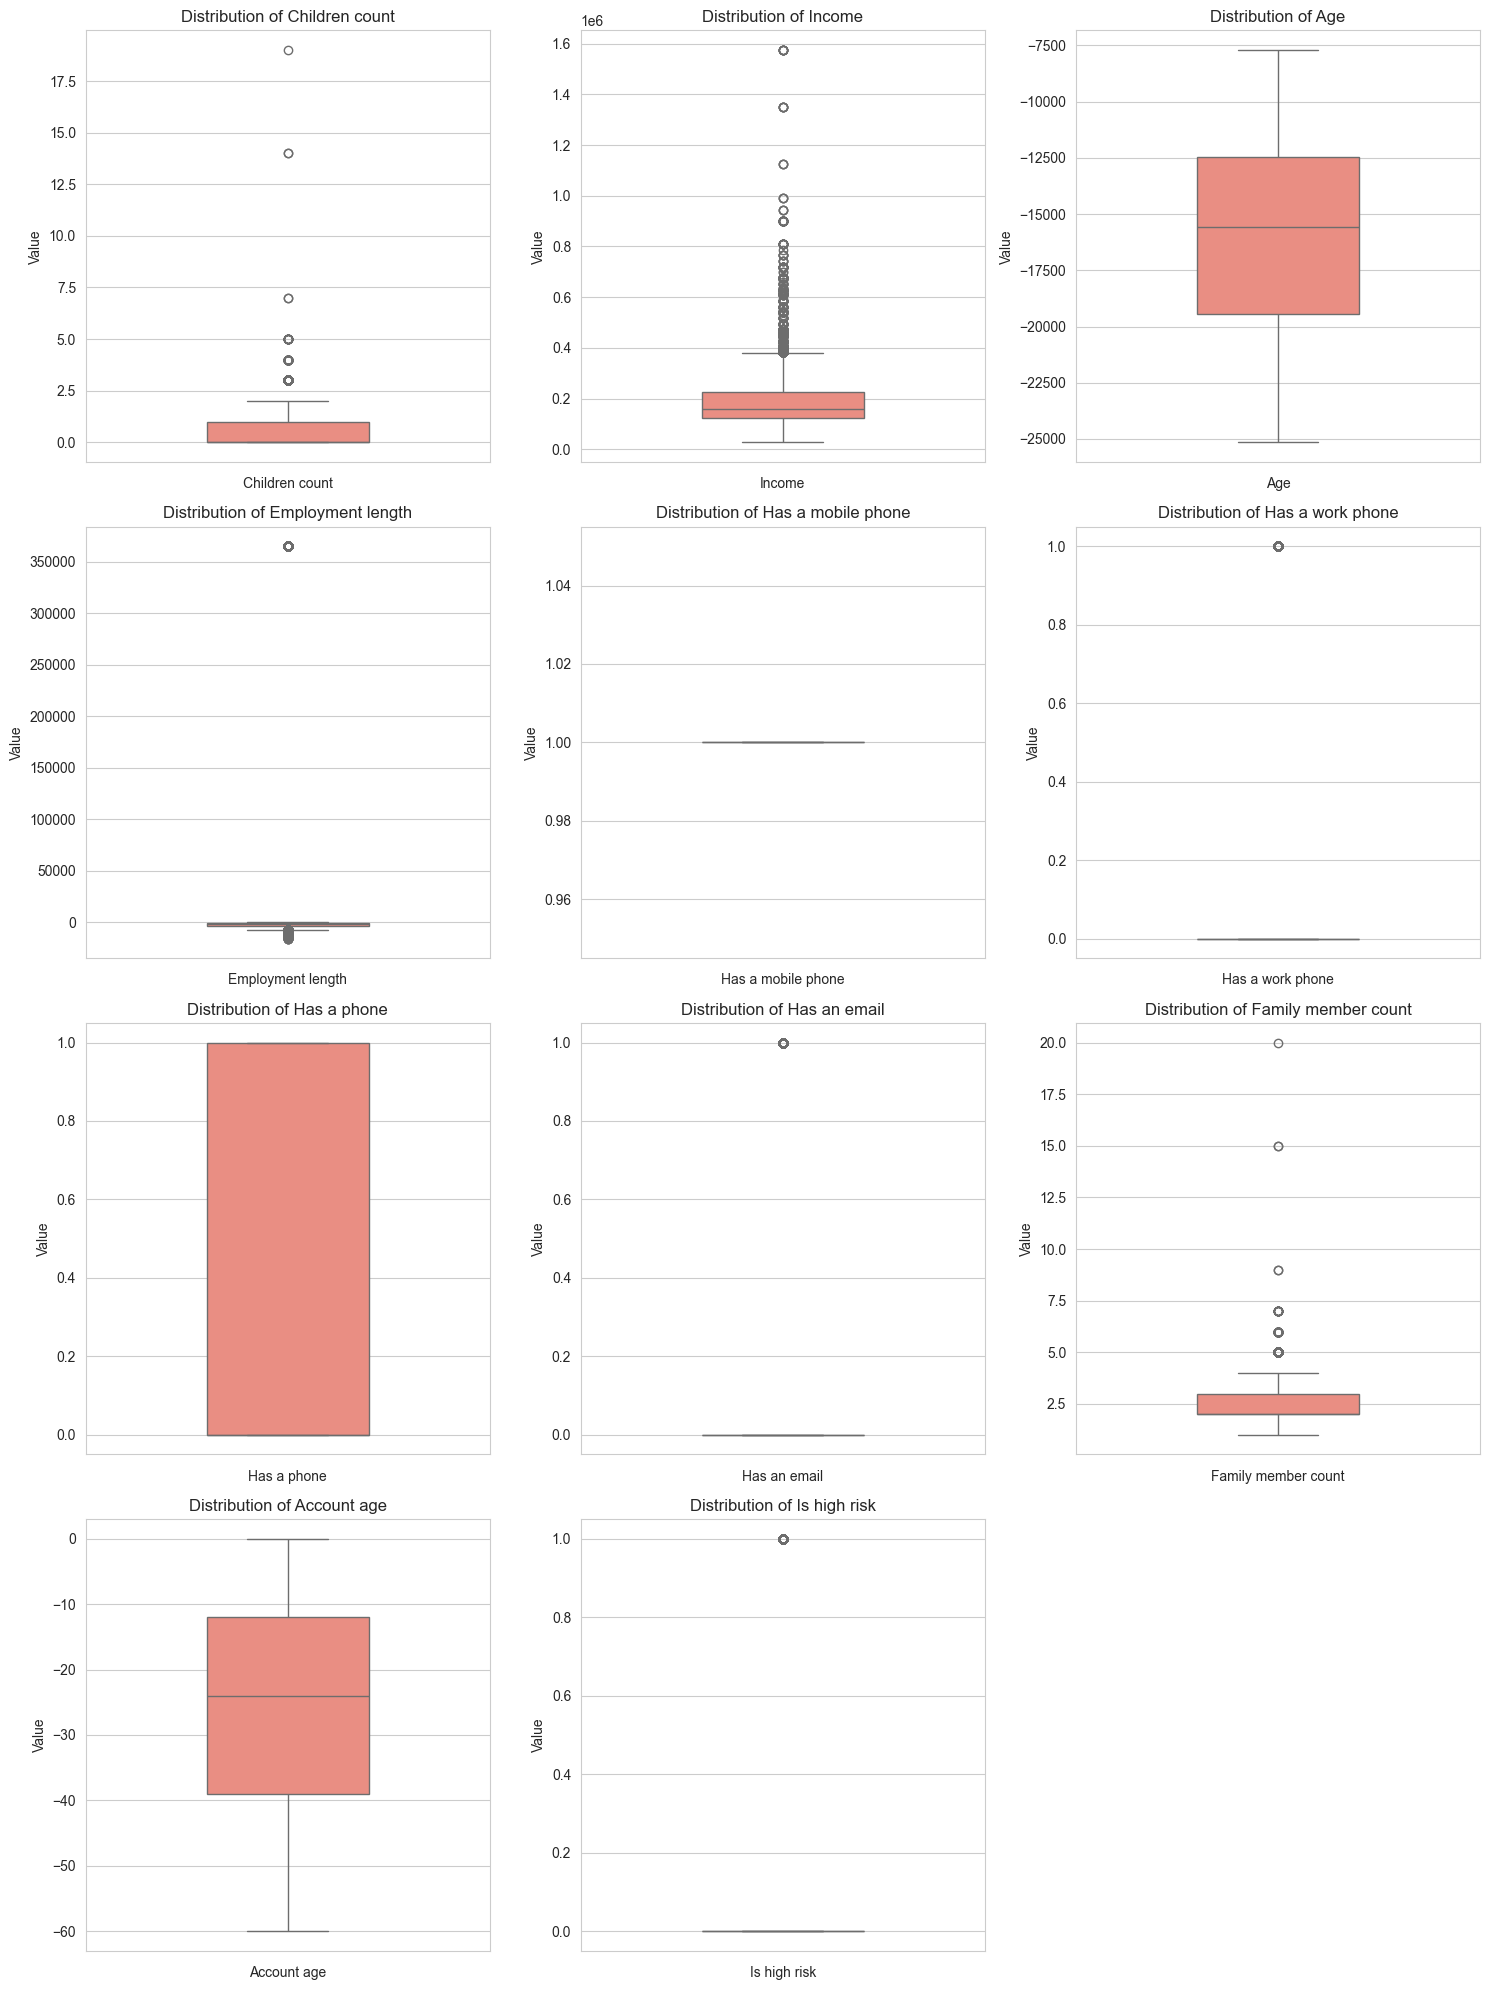

In [9]:
num_features = train_data.select_dtypes(include=[np.number]).columns.tolist()
features_to_plot = [f for f in num_features if f.lower() != 'id']

n_cols = 3
n_rows = math.ceil(len(features_to_plot) / n_cols)

sns.set_style('whitegrid')
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.boxplot(y=train_data[feature], ax=axes[i], color='salmon', width=0.4)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_ylabel('Value')
    axes[i].set_xlabel(feature)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 5.2 Categorical Feature Distributions (Count Plots)
Count plots show the class balance within each categorical column — important for understanding potential bias.


Categorical columns: ['Gender', 'Has a car', 'Has a property', 'Employment status', 'Education level', 'Marital status', 'Dwelling', 'Job title']


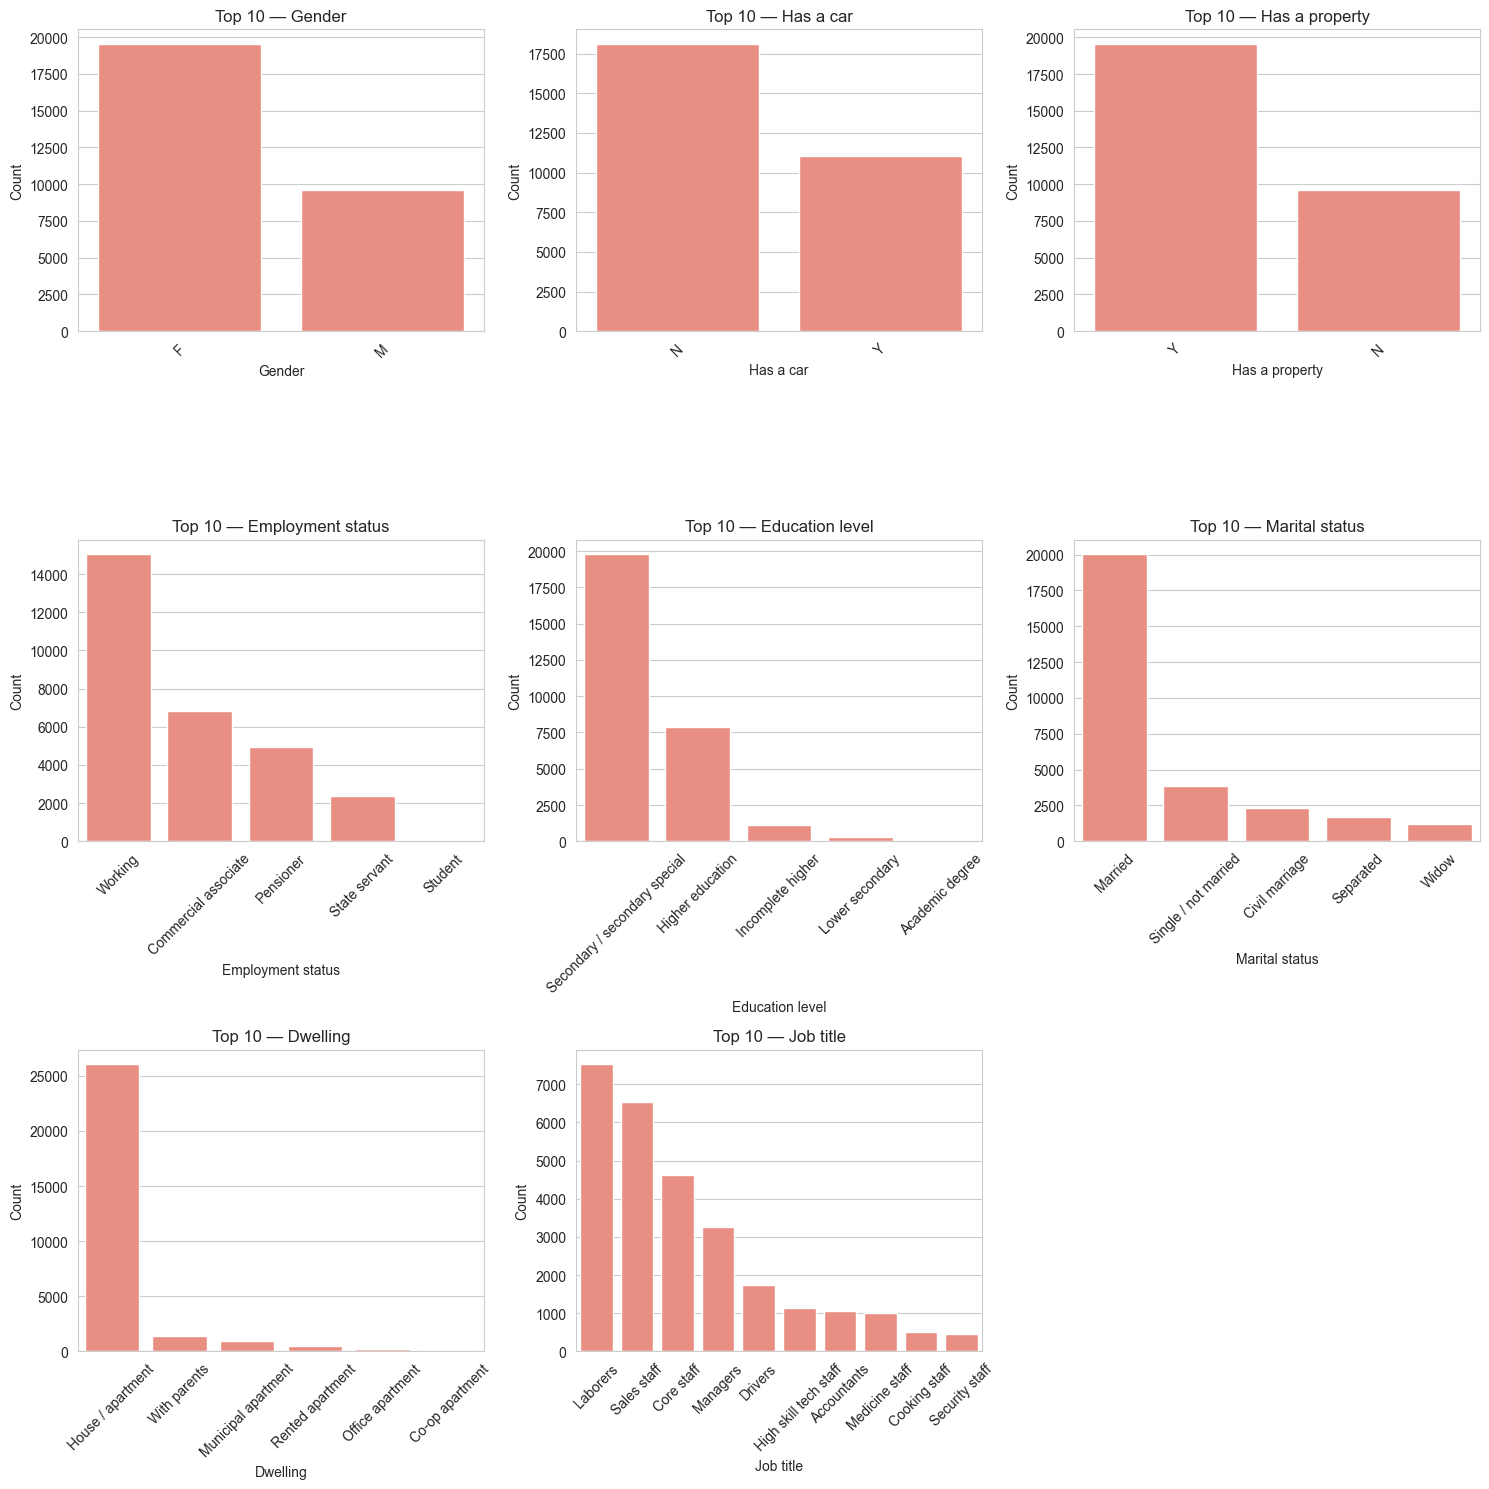

In [10]:
cat_columns = train_data.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns:', cat_columns)

n_cols = 3
n_rows = math.ceil(len(cat_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, feature in enumerate(cat_columns):
    top10 = train_data[feature].value_counts().head(10).index
    sns.countplot(x=train_data[train_data[feature].isin(top10)][feature],
                  ax=axes[i], color='salmon', order=top10)
    axes[i].set_title(f'Top 10 — {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 5.3 Correlation Heatmap
The heatmap shows pairwise linear correlations between all numeric features.
Values close to **+1** indicate strong positive correlation; close to **-1** indicate strong negative correlation.
High inter-feature correlation can indicate redundancy.


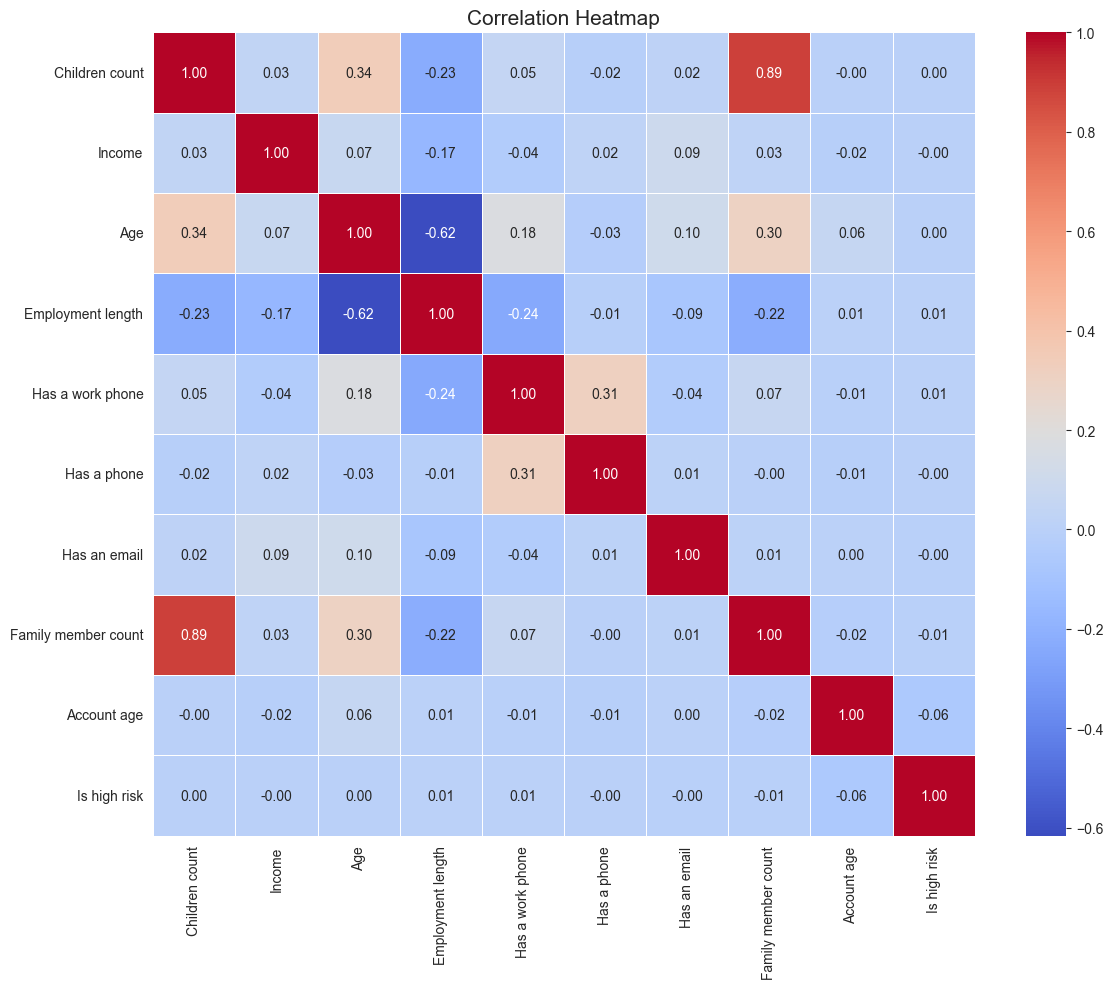

In [11]:
df_corr = train_data.select_dtypes(include=['number']).drop(columns=['ID'], errors='ignore')

# Remove constant columns (std == 0) to avoid NaN in correlation
df_corr = df_corr.loc[:, df_corr.std() > 0]

plt.figure(figsize=(12, 10))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 10}
)
plt.title('Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.show()


---
## 6️⃣ Feature Engineering (Training Data)

Raw features are often not the most informative representation. We create **derived features** that capture richer signals:

| New Feature | Formula | Intuition |
|---|---|---|
| `Income_per_member` | `Income / Family member count` | Financial burden per person |
| `Age_years` | `abs(Age) / 365` | Age in years (raw value stored as negative days) |
| `Employed_years` | `abs(Employment length) / 365` | Years in current job |
| `Work_life_ratio` | `Employed_years / Age_years` | Proportion of life spent employed |
| `Total_comm_channels` | sum of work phone + home phone + email | Accessibility / stability proxy |

> ⚠️ `Age` and `Employment length` are stored as **negative integers representing days** (a common credit bureau convention). We convert them with `abs() / 365`.


In [12]:
# 1. Income normalised by family size
train_data['Income_per_member'] = train_data['Income'] / train_data['Family member count']

# 2. Convert age and employment length from negative days → positive years
train_data['Age_years']      = abs(train_data['Age'])               / 365
train_data['Employed_years'] = abs(train_data['Employment length']) / 365

# 3. Ratio of life spent employed
train_data['Work_life_ratio'] = train_data['Employed_years'] / train_data['Age_years']

# 4. Number of communication channels (work phone + home phone + email)
train_data['Total_comm_channels'] = (
    train_data[['Has a work phone', 'Has a phone', 'Has an email']].sum(axis=1)
)

# Drop original columns now replaced by engineered features
train_data.drop(columns=['Age', 'Employment length'], inplace=True)

print('New features added. Shape:', train_data.shape)
train_data[['Income_per_member', 'Age_years', 'Employed_years',
            'Work_life_ratio', 'Total_comm_channels']].head()


New features added. Shape: (29165, 23)


,Income_per_member,Age_years,Employed_years,Work_life_ratio,Total_comm_channels
0,67500.0,44.578082,8.523288,0.191199,0
1,67500.0,27.753425,4.523288,0.162981,0
2,45000.0,35.126027,15.498630,0.441229,0
3,360000.0,57.339726,5.605479,0.097759,1
4,270000.0,44.402740,1.410959,0.031776,1


---
## 7️⃣ Preprocess Test Data

We apply the **exact same transformations** to the test set to avoid train/test mismatch:
1. Impute missing `Job title` values
2. Engineer the same derived features
3. Drop columns that were removed from training data

> 🔑 Consistency is critical: any transformation applied to training data must be replicated on test data.


In [13]:
test_data = pd.read_csv('test_data.csv')

# --- Missing value imputation ---
test_data['Job title'] = test_data['Job title'].fillna(
    test_data['Job title'].mode()[0]
)

# --- Feature Engineering (mirror of training) ---
test_data['Income_per_member']    = test_data['Income'] / test_data['Family member count']
test_data['Age_years']            = abs(test_data['Age'])               / 365
test_data['Employed_years']       = abs(test_data['Employment length']) / 365
test_data['Work_life_ratio']      = test_data['Employed_years'] / test_data['Age_years']
test_data['Total_comm_channels']  = (
    test_data[['Has a work phone', 'Has a phone', 'Has an email']].sum(axis=1)
)

# --- Drop columns removed from training ---
test_data.drop(
    columns=['ID', 'Age', 'Employment length', 'Has a mobile phone'],
    inplace=True, errors='ignore'
)

print('Test data preprocessed. Shape:', test_data.shape)


Test data preprocessed. Shape: (7292, 21)


---
## 8️⃣ Categorical Encoding

Machine learning models require **numeric inputs**. We use **One-Hot Encoding** (`get_dummies`) for categorical columns.

- `drop_first=True` removes one dummy per column to avoid multicollinearity (the *dummy variable trap*).
- We check at runtime which columns still exist (some may have been dropped earlier) to avoid `KeyError`.

**Columns to encode:** `Employment status`, `Education level`, `Marital status`, `Dwelling`, `Job title`


In [14]:
categorical_cols = [
    'Employment status', 'Education level',
    'Marital status', 'Dwelling', 'Job title'
]

# Only encode columns that are still present
cols_to_encode = [c for c in categorical_cols if c in train_data.columns]

if cols_to_encode:
    train_data = pd.get_dummies(train_data, columns=cols_to_encode, drop_first=True)
    print(f'Encoded columns: {cols_to_encode}')
else:
    print('Columns already encoded or not found — skipping.')

print('Shape after encoding:', train_data.shape)


Encoded columns: ['Employment status', 'Education level', 'Marital status', 'Dwelling', 'Job title']
Shape after encoding: (29165, 52)


---
## 9️⃣ Define Features, Split & Scale

### Train / Validation Split
We hold out **20%** of training data as a validation set to measure model performance without touching the test set.
`stratify=y` ensures both splits have the same proportion of high-risk applicants.

### Standard Scaling
`StandardScaler` transforms features to zero mean and unit variance — important for distance-based models (Logistic Regression, SVM, KNN).

> ⚠️ The scaler is **fit only on training data** (`fit_transform`) and then merely **applied** to validation data (`transform`) to prevent data leakage.


In [17]:
# 1. Separate features and target
X = train_data.drop('Is high risk', axis=1)
y = train_data['Is high risk']

# 2. Train / validation split (80 / 20, stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale: fit on train only, transform both
# 1. Manual Mapping for Binary Columns (Gender, etc.)
# This turns 'F' into 0 and 'M' into 1
binary_cols = {
    'Gender': {'F': 0, 'M': 1},
    'Has a car': {'N': 0, 'Y': 1},
    'Has a property': {'N': 0, 'Y': 1}
}

for col, mapping in binary_cols.items():
    if col in train_data.columns:
        train_data[col] = train_data[col].map(mapping)

# 2. One-Hot Encoding for the rest
# This handles 'Education level', 'Job title', etc.
categorical_cols = ['Employment status', 'Education level', 'Marital status', 'Dwelling', 'Job title']
train_data = pd.get_dummies(train_data, columns=[c for c in categorical_cols if c in train_data.columns], drop_first=True)

# 3. Double-check: Ensure NO objects/strings are left
print("Remaining non-numeric columns:", train_data.select_dtypes(include=['object']).columns.tolist())

# 4. NOW redo the split and scaling
X = train_data.drop('Is high risk', axis=1)
y = train_data['Is high risk']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Scaling successful!")

print(f'Train samples : {X_train.shape[0]}')
print(f'Val   samples : {X_val.shape[0]}')
print(f'Features      : {X_train.shape[1]}')
print('Scaler fitted on training data ✅')


Remaining non-numeric columns: []
Scaling successful!
Train samples : 23332
Val   samples : 5833
Features      : 51
Scaler fitted on training data ✅


---
## 🔟 Model Training — XGBoost Classifier

**XGBoost** (Extreme Gradient Boosting) is a highly effective ensemble method that builds trees sequentially, each one correcting the errors of the previous.

### Why XGBoost for credit risk?
- Handles **class imbalance** natively via `scale_pos_weight`
- Built-in **regularisation** (L1 + L2) to prevent overfitting
- Works well with **mixed feature types** (numeric + encoded categoricals)
- Fast training via parallel tree construction

### Key hyperparameters used
| Parameter | Value | Purpose |
|---|---|---|
| `n_estimators` | 300 | Number of boosting rounds |
| `max_depth` | 5 | Max tree depth — controls complexity |
| `learning_rate` | 0.05 | Shrinkage — smaller = more robust |
| `subsample` | 0.8 | Row sampling per tree — reduces overfitting |
| `colsample_bytree` | 0.8 | Feature sampling per tree |
| `scale_pos_weight` | auto | Balances positive/negative class ratio |
| `eval_metric` | `auc` | Optimise for ROC-AUC during training |


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Class imbalance weight ---
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos   # scale_pos_weight
print(f'Class ratio (neg/pos): {spw:.2f}  →  scale_pos_weight = {spw:.2f}')

# --- Define model ---
xgb_model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = spw,
    eval_metric       = 'auc',
    early_stopping_rounds = 20,
    random_state      = 42,
    n_jobs            = -1
)

# --- Train with early stopping ---
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=50
)

print(f'\nBest iteration: {xgb_model.best_iteration}')


---
## 1️⃣1️⃣ Model Evaluation

We evaluate the model using four complementary metrics:

| Metric | What it tells us |
|---|---|
| **Classification Report** | Precision, Recall, F1 per class |
| **ROC-AUC Score** | Overall discrimination ability (higher = better) |
| **Confusion Matrix** | True/False Positives and Negatives |
| **ROC Curve** | Trade-off between TPR and FPR at all thresholds |

> 🎯 For credit risk, **Recall on the high-risk class** is especially important — missing a risky applicant is more costly than a false alarm.


In [ ]:
# --- Predictions ---
y_pred       = xgb_model.predict(X_val_scaled)
y_pred_proba = xgb_model.predict_proba(X_val_scaled)[:, 1]

# --- Classification Report ---
print('=' * 55)
print('           CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_val, y_pred,
      target_names=['Low Risk (0)', 'High Risk (1)']))

# --- ROC-AUC ---
auc = roc_auc_score(y_val, y_pred_proba)
print(f'ROC-AUC Score : {auc:.4f}')


In [ ]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk']
)
plt.title('Confusion Matrix — XGBoost', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


In [ ]:
# --- ROC Curve ---
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_val, y_pred_proba,
    name=f'XGBoost (AUC = {auc:.3f})',
    ax=ax, color='steelblue'
)
ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_title('ROC Curve — XGBoost', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


---
## 1️⃣2️⃣ Feature Importance

XGBoost provides a built-in feature importance score based on how often each feature is used in a split (`weight`) or its average gain.

The top features here reveal which applicant attributes drive the risk prediction most.


In [ ]:
importances = xgb_model.feature_importances_
feature_names = X_train.columns

feat_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importances — XGBoost', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


---
## 1️⃣3️⃣ Generate Test Predictions & Export

Apply the trained model to the test set and export predictions to a CSV file ready for submission.


In [ ]:
# Align test columns with training columns (fill any missing dummies with 0)
test_encoded = pd.get_dummies(test_data)
test_encoded = test_encoded.reindex(columns=X_train.columns, fill_value=0)

# Scale using the already-fitted scaler
test_scaled = scaler.transform(test_encoded)

# Predict
test_preds       = xgb_model.predict(test_scaled)
test_preds_proba = xgb_model.predict_proba(test_scaled)[:, 1]

# Build submission dataframe
submission = pd.DataFrame({
    'ID'           : range(len(test_preds)),
    'Is high risk' : test_preds,
    'Probability'  : test_preds_proba.round(4)
})

submission.to_csv('submission.csv', index=False)
print(f'Saved {len(submission)} predictions → submission.csv')
submission.head(10)


---
## ✅ Complete Pipeline Summary

| Step | Details |
|---|---|
| Data loaded | `train_data.csv` + `test_data.csv` |
| Missing values | Group-mode imputation for `Job title` |
| Features engineered | `Income_per_member`, `Age_years`, `Work_life_ratio`, `Total_comm_channels` |
| Encoding | Binary mapping + One-Hot Encoding |
| Scaling | `StandardScaler` (fit on train only) |
| Model | `XGBClassifier` with early stopping & class balancing |
| Evaluation | Classification report · ROC-AUC · Confusion matrix · ROC curve |
| Output | `submission.csv` with predictions and probabilities |
